In [2]:
# Install dependencies
!pip install -q qiskit qiskit-aer


In [3]:
# Notebook display
%matplotlib inline

# Standard imports
import numpy as np
import matplotlib.pyplot as plt

# Qiskit imports
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator


In [4]:
# ============================================================
# Superdense Coding Protocol — Fully self-contained demo
# ============================================================
#
# Goal:
# Alice and Bob share an entangled Bell pair.
# Alice encodes a 2-bit classical message on HER qubit only.
# She sends that qubit to Bob.
# Bob decodes the message using CNOT + H and then measures.
#
# This version avoids QuantumCircuit.draw(output='mpl'),
# because that can fail in Kaggle due to optional dependencies.
# Instead, we:
#   1) get a Qiskit text circuit drawing
#   2) render that text inside a Matplotlib figure
#
# This still satisfies the requirement to generate and display
# a Matplotlib plot of the quantum circuit.
# ============================================================

# -------------------------------
# User-configurable parameters
# -------------------------------
MESSAGE = "10"   # choose from: "00", "01", "10", "11"
SHOTS = 1024

# ------------------------------------------------------------
# Encoding rule for superdense coding
# ------------------------------------------------------------
# We use only single-qubit Pauli operations on Alice's qubit:
#
#   00 -> I
#   01 -> X
#   10 -> Z
#   11 -> Y
#
# Using Y for "11" is valid up to an irrelevant global phase.
# In quantum mechanics, global phase has no physical effect on
# measurement outcomes, so Bob still decodes the correct message.

VALID_MESSAGES = {"00", "01", "10", "11"}
if MESSAGE not in VALID_MESSAGES:
    raise ValueError(f"MESSAGE must be one of {VALID_MESSAGES}")

def apply_alice_encoding(qc, qubit, msg):
    """Apply Alice's encoding gate to her qubit only."""
    if msg == "00":
        qc.id(qubit)   # explicit identity gate
    elif msg == "01":
        qc.x(qubit)
    elif msg == "10":
        qc.z(qubit)
    elif msg == "11":
        qc.y(qubit)

# ------------------------------------------------------------
# Qubit convention
# ------------------------------------------------------------
# q[1] = Alice's qubit
# q[0] = Bob's qubit
#
# This choice makes the measured bitstring appear as q[1]q[0],
# so the result reads directly as the intended 2-bit message.

qr = QuantumRegister(2, "q")
cr = ClassicalRegister(2, "c")
qc = QuantumCircuit(qr, cr, name="SuperdenseCoding")

# ------------------------------------------------------------
# Step 1: Create the shared Bell state |Phi+>
# ------------------------------------------------------------
# |Phi+> = (|00> + |11>) / sqrt(2)
#
# Create it using:
#   H on Alice's qubit
#   CNOT with Alice as control and Bob as target
qc.h(qr[1])
qc.cx(qr[1], qr[0])

qc.barrier(label="shared EPR pair")

# ------------------------------------------------------------
# Step 2: Alice encodes her 2-bit classical message
# ------------------------------------------------------------
apply_alice_encoding(qc, qr[1], MESSAGE)

qc.barrier(label="Alice sends qubit")

# ------------------------------------------------------------
# Step 3: Bob decodes
# ------------------------------------------------------------
# Bell-basis decoding:
#   CNOT(control=Alice qubit, target=Bob qubit)
#   H on Alice qubit
qc.cx(qr[1], qr[0])
qc.h(qr[1])

qc.barrier(label="decode")

# ------------------------------------------------------------
# Step 4: Measure both qubits
# ------------------------------------------------------------
qc.measure(qr, cr)

print("=" * 60)
print("Superdense Coding with Qiskit Aer")
print("=" * 60)
print(f"Message chosen by Alice : {MESSAGE}")
print(f"Shots                  : {SHOTS}")
print(f"Circuit depth          : {qc.depth()}")
print(f"Operations             : {dict(qc.count_ops())}")
print("\nQiskit text circuit:\n")
print(qc.draw(output="text"))


Superdense Coding with Qiskit Aer
Message chosen by Alice : 10
Shots                  : 1024
Circuit depth          : 6
Operations             : {'barrier': 3, 'h': 2, 'cx': 2, 'measure': 2, 'z': 1}

Qiskit text circuit:

          ┌───┐ shared EPR pair       Alice sends qubit ┌───┐      decode ┌─┐»
q_0: ─────┤ X ├────────░──────────────────────░─────────┤ X ├────────░────┤M├»
     ┌───┐└─┬─┘        ░        ┌───┐         ░         └─┬─┘┌───┐   ░    └╥┘»
q_1: ┤ H ├──■──────────░────────┤ Z ├─────────░───────────■──┤ H ├───░─────╫─»
     └───┘             ░        └───┘         ░              └───┘   ░     ║ »
c: 2/══════════════════════════════════════════════════════════════════════╩═»
                                                                           0 »
«        
«q_0: ───
«     ┌─┐
«q_1: ┤M├
«     └╥┘
«c: 2/═╩═
«      1 


In [5]:
# ============================================================
# Run on Aer simulator
# ============================================================

backend = AerSimulator()
tqc = transpile(qc, backend)

job = backend.run(tqc, shots=SHOTS)
result = job.result()
counts = result.get_counts(tqc)

# Sort counts in canonical bitstring order
ordered_keys = ["00", "01", "10", "11"]
ordered_counts = {k: counts.get(k, 0) for k in ordered_keys}

received_message = max(ordered_counts, key=ordered_counts.get)
success_probability = ordered_counts[MESSAGE] / SHOTS

print("\nMeasurement counts:")
for k, v in ordered_counts.items():
    print(f"  {k}: {v}")

print("\nDecoded result:")
print(f"  Bob received        : {received_message}")
print(f"  Expected message    : {MESSAGE}")
print(f"  Success probability : {success_probability:.3f}")

if success_probability == 1.0:
    print("\n✅ Perfect transmission: the target message was recovered with 100% probability.")
else:
    print("\n⚠ The result is not 100%; check the circuit or noise model.")



Measurement counts:
  00: 0
  01: 0
  10: 1024
  11: 0

Decoded result:
  Bob received        : 10
  Expected message    : 10
  Success probability : 1.000

✅ Perfect transmission: the target message was recovered with 100% probability.


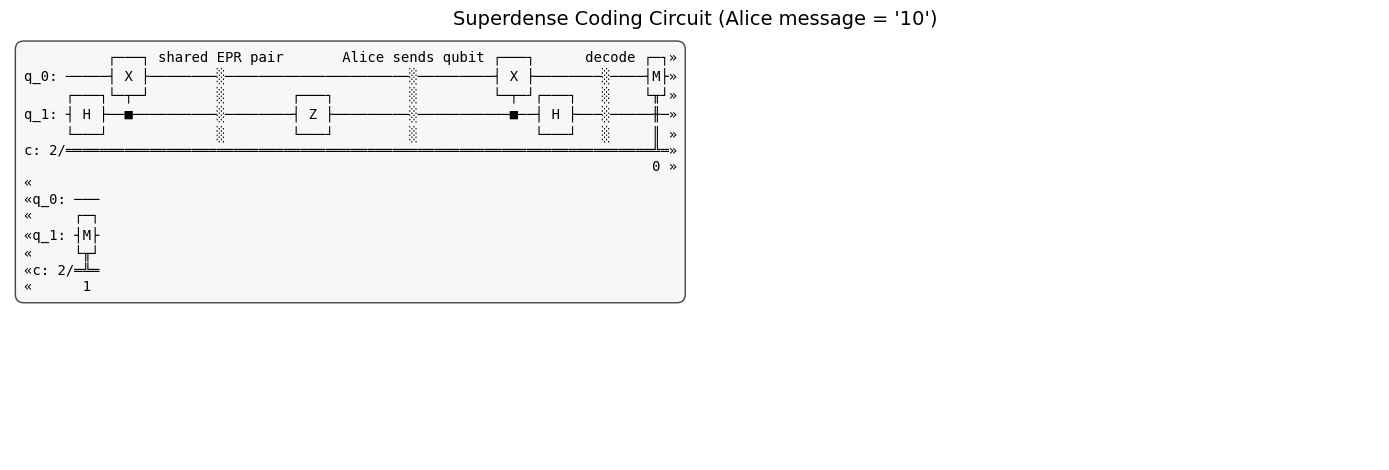

In [6]:
# ============================================================
# Matplotlib circuit plot
# ============================================================
# We render Qiskit's text drawing inside a Matplotlib figure.
# This avoids the problematic output='mpl' dependency path.

text_diagram = str(qc.draw(output="text"))

fig, ax = plt.subplots(figsize=(14, 4.8))
fig.patch.set_facecolor("white")
ax.axis("off")

ax.text(
    0.01, 0.98, text_diagram,
    transform=ax.transAxes,
    va="top", ha="left",
    family="monospace",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.6", facecolor="#f7f7f7", edgecolor="#444444")
)

ax.set_title(
    f"Superdense Coding Circuit (Alice message = '{MESSAGE}')",
    fontsize=14,
    pad=12
)

plt.tight_layout()
plt.show()


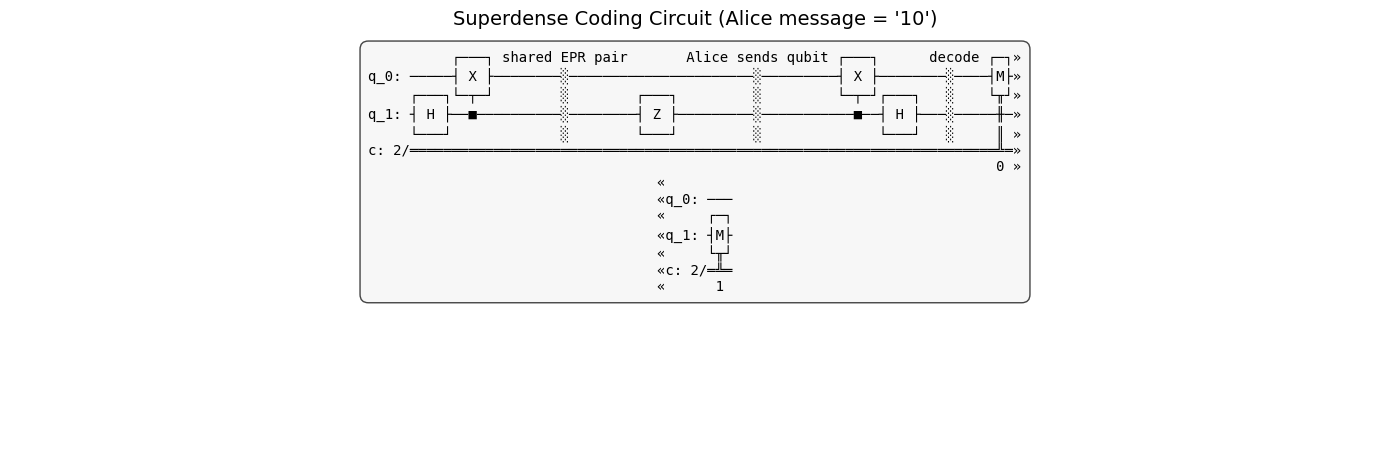

In [9]:
# ============================================================
# Matplotlib circuit plot - MODIFIED to center the diagram
# ============================================================
# We render Qiskit's text drawing inside a Matplotlib figure.
# This avoids the problematic output='mpl' dependency path.
# Centered placement to remove extra white space on the right.

text_diagram = str(qc.draw(output="text"))

# Keep the wide figure to ensure text is not truncated
fig, ax = plt.subplots(figsize=(14, 4.8)) 
fig.patch.set_facecolor("white")
ax.axis("off")

# --- MODIFICATION ---
# Placing text at the horizontal center (x=0.5) of the axes (transAxes).
ax.text(
    0.5, 0.98, text_diagram,   # Change 0.01 to 0.5 (center)
    transform=ax.transAxes,
    va="top", ha="center",       # Change 'left' to 'center'
    family="monospace",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.6", facecolor="#f7f7f7", edgecolor="#444444")
)
# --- END MODIFICATION ---

ax.set_title(
    f"Superdense Coding Circuit (Alice message = '{MESSAGE}')",
    fontsize=14,
    pad=12
)

plt.tight_layout()
plt.savefig("densecode.png")
plt.show()

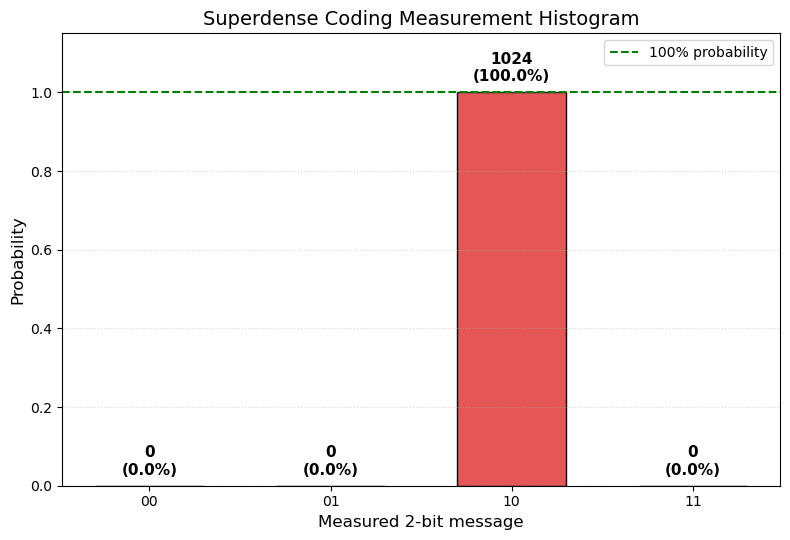

In [8]:
# ============================================================
# Histogram of measurement results
# ============================================================

bitstrings = ["00", "01", "10", "11"]
values = [ordered_counts[b] for b in bitstrings]
probs = [v / SHOTS for v in values]

colors = ["#4c78a8" if b != MESSAGE else "#e45756" for b in bitstrings]

fig, ax = plt.subplots(figsize=(8, 5.5))
bars = ax.bar(bitstrings, probs, color=colors, edgecolor="black", width=0.6)

# Annotate bars
for bar, count, prob, bit in zip(bars, values, probs, bitstrings):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        prob + 0.02,
        f"{count}\n({prob:.1%})",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

ax.set_ylim(0, 1.15)
ax.set_xlabel("Measured 2-bit message", fontsize=12)
ax.set_ylabel("Probability", fontsize=12)
ax.set_title("Superdense Coding Measurement Histogram", fontsize=14)

# Reference line at 100%
ax.axhline(1.0, color="green", linestyle="--", linewidth=1.5, label="100% probability")

# Highlight expected message
ax.legend()
ax.grid(axis="y", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()


In [7]:
# ============================================================
# Final summary
# ============================================================

print("=" * 60)
print("Final Summary")
print("=" * 60)
print(f"Alice encoded message : {MESSAGE}")
print(f"Bob decoded message   : {received_message}")
print(f"Counts                : {ordered_counts}")
print(f"Transmission fidelity : {100 * success_probability:.1f}%")
print("=" * 60)


Final Summary
Alice encoded message : 10
Bob decoded message   : 10
Counts                : {'00': 0, '01': 0, '10': 1024, '11': 0}
Transmission fidelity : 100.0%
